In [7]:
from IPython.core.display_functions import clear_output
!pip install pandas
!pip install numpy
!pip install tensorflow
!pip install seaborn
clear_output()

## Multiplicación de matrices

Debido a la facilidad, y partiendo de las bases creadas en el taller anterior, se desarrollo un modelo de multiplicación matricial 2x2, con valores continuos entre -20 y 20, con la ayuda de pandas y tensorflow

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf

### Dataframe
El primer paso es poblar un dataframe de tamaño 62500 (80% entrenamiento-50000 y 20% Validación-12500) con valores aleatorios, luego de esto, se realiza la multiplicación para cada elemento de la matriz resultante **R**

In [9]:
a11=np.random.random(62500)*40-20
a12=np.random.random(62500)*40-20
a21=np.random.random(62500)*40-20
a22=np.random.random(62500)*40-20

b11=np.random.random(62500)*40-20
b12=np.random.random(62500)*40-20
b21=np.random.random(62500)*40-20
b22=np.random.random(62500)*40-20


df=pd.DataFrame({   'a11':a11,
                    'a12':a12,
                    'a21':a21,
                    'a22':a22,
                    'b11':b11,
                    'b12':b12,
                    'b21':b21,
                    'b22':b22,
                    })

print(len(df),len(df.drop_duplicates()))

df['R11']=(df['a11']*df['b11'])+(df['a12']*df['b21'])
df['R12']=(df['a11']*df['b12'])+(df['a12']*df['b22'])
df['R21']=(df['a21']*df['b11'])+(df['a22']*df['b21'])
df['R22']=(df['a21']*df['b12'])+(df['a22']*df['b22'])

df_train=df[:50000]
df_test=df[50000:56250]
df_test_2=df[56250:]

print(len(df_train), len(df_test))

df.head(2)

62500 62500
50000 6250


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22
0,3.889099,-3.461882,-9.465485,-4.639848,-7.389575,0.985601,-4.348770,2.945895,-13.683860,-6.365239,90.123538,-22.997702
1,-11.846291,15.403788,15.436270,-4.271208,-15.351772,10.365217,18.686768,-9.807277,469.708575,-273.858597,-316.789173,201.889210


### Definición del modelo

Para la definición del modelo, se selecciónan las columnas que haran parte de las entradas y las columnas correspondientes a la salida, en este caso, es un modelo con 8 entradas (correspondientes a 2 veces el tamaño de una matriz) y una salida de tamaño 4 (una vez el tamaño de la matriz), en el medio, se usa una capa con mayor densidad de neuronas, para converger mas rapido al resultado

In [10]:
salidas=['R11','R12','R21','R22']
entradas=['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22']
tamaño=len(entradas)

x=[]

for i in entradas:
    x.append(df_train[i])

X=np.column_stack(x)

y=[]

for i in salidas:
    y.append(df_train[i])

Y=np.column_stack(y)

entrada = tf.keras.layers.Dense(units=tamaño, input_shape=[tamaño], activation="relu")
c1 = tf.keras.layers.Dense(units=64, activation="relu")
salida = tf.keras.layers.Dense(units=4, activation="linear")
red = tf.keras.Sequential([entrada, c1, salida])
red.compile(optimizer='adam',
            loss="mse",
            metrics=['accuracy'])

/home/robotica/Jupyter_lab/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Se realiza el entrenamiento del modelo, al tener pocas capas,y relativamente pocos parametros, se usa una enorme cantidad de epocas, **para mejorar el tiempo de ejecución, se comenta el entrenamieno y se carga el modelo preentrenado, sin embargo descomentando las dos lineas de codigo adicionales y comentando la carga del modelo se puede volver a entrenar el modelo.**

In [ ]:
#red= tf.keras.models.load_model("Light_model.keras")
historial = red.fit(X, Y, epochs=5000, verbose=False)
red.save("Light_model.keras")

### Verificación del modelo

Ahora, se evalua la capacidad del modelo, con la ayuda del dataframe de validación, en el cual se añaden las columnas correspondientes a los 4 valores predichos por el modelo.

In [ ]:
def clasificar_dataframe(df, modelo, columnas, salidas):
    X = df[columnas].values
    preds = modelo.predict(X)

    for i in range(len(salidas)):
        df[salidas[i]] = preds[:,i]
#    df['R11_a'] = preds[:,0]
    #df['Predeccion']=(preds > 0.5).astype(int)
    return df

salidas_2 = []
errores= []
for i in salidas:
    salidas_2.append(f'{i}_pred')
    errores.append(f'{i}_error')

clasificar_dataframe(df_test, red, entradas, salidas_2)

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,...,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
50000,1.127082,14.163765,13.602311,-11.603538,9.381976,13.154379,3.694259,-5.202033,62.898874,-58.854305,...,239.291938,51.200520,-53.056725,104.329659,230.045700,0.300637,6.932410,2.392598,2.634921,3.065141
50001,0.664790,2.134267,5.969541,19.058455,19.584679,-13.369941,16.811842,-10.579050,48.900655,-31.466718,...,-281.432753,43.097935,-25.819839,431.609039,-268.366852,3.460073,5.611781,1.581429,0.869373,2.880664
50002,-0.075914,5.132543,15.300683,16.045216,9.611008,-11.677043,-7.365658,-12.342538,-38.534162,-62.462166,...,-376.705410,-48.546688,-44.716820,33.536789,-383.515747,9.492813,3.827243,7.854530,0.180082,5.338667
50003,14.279632,2.816678,5.534494,19.724783,9.166213,11.177653,7.007757,-11.416642,150.628740,127.455770,...,-163.328139,184.125305,139.541351,188.347809,-162.776718,2.626745,2.646132,2.346433,2.469339,2.522162
50004,8.423579,2.652924,-4.942375,-2.149796,-16.921660,-18.128385,7.937509,12.893108,-121.483332,-118.501456,...,61.879724,-124.643692,-134.162079,65.111855,65.167618,1.048644,4.318486,0.142081,4.240618,2.437457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62495,-14.257520,-19.524279,-6.898288,-9.016148,12.532176,-9.227630,4.262808,2.053661,-261.905991,91.466861,...,45.138738,-280.118500,98.589119,-114.992485,44.768005,1.450472,0.908832,3.878456,5.990946,3.057176
62496,-10.996838,3.591104,11.517683,-14.002746,-6.433719,19.597036,-19.097760,13.746269,2.168529,-166.141151,...,33.226937,11.326189,-172.632996,190.613098,34.277336,387.544182,1.699042,0.207213,29.506824,104.739315
62497,-2.630988,6.200288,-13.309001,16.364841,4.640500,8.369401,16.020596,9.461475,87.123217,36.644081,...,43.447169,96.005768,49.969910,214.217987,34.967297,1.922959,4.274338,4.024774,8.720406,4.735619
62498,-3.407271,2.034820,-11.360571,-6.290067,9.207344,-0.774081,11.809812,4.703824,-7.341078,12.208935,...,-20.793366,18.791262,11.055946,-164.004028,-11.269860,11.892472,0.829797,3.675815,15.890077,8.072040


Se evalua el error absoluto para cada elemento del resultado y se promedia el error obtenido para toda la matriz, **El dataframe presentado en la siguiente casilla, esta ordenado de forma descendente por el mayor error medio para el conjunto, es decir que se presentan los peores resultados**, con esto en mente, es notable que en la mayoria de los casos, el mayor error presentado es debido a que el modelo se equivoca en la predicción de los valores muy pequeños, generando una alta desviación, y es notable, que el el valor nro 100 mas alto corresponda a 617%, lo que ubica a los restantes 12400 como mejores evaluaciones de la multiplicación de matrices.

In [ ]:
for i in zip(salidas, salidas_2, errores):
    df_test[i[2]]=np.abs((df_test[i[0]]-df_test[i[1]])/df_test[i[0]])*100

df_test['error_media'] = df_test[errores].mean(axis=1)

df_test[salidas+salidas_2+errores+['error_media']].sort_values(by='error_media', ascending=False).round(2).head(100)

('R11', 'R11_pred', 'R11_error')
('R12', 'R12_pred', 'R12_error')
('R21', 'R21_pred', 'R21_error')
('R22', 'R22_pred', 'R22_error')
49.27864125722596
['R11', 'R12', 'R21', 'R22', 'R11_pred', 'R12_pred', 'R21_pred', 'R22_pred', 'R11_error', 'R12_error', 'R21_error', 'R22_error', 'error_media']


,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
57399,-0.02,5.52,-282.25,-47.96,-16.870001,5.540000,-275.690002,-63.459999,87673.97,0.46,2.32,32.30,21927.26
55209,-0.02,66.75,-435.33,-215.61,20.299999,52.250000,-453.429993,-207.880005,84125.74,21.72,4.16,3.58,21038.80
56526,-0.02,-37.60,49.83,-160.22,-13.170000,-21.670000,39.610001,-153.259995,81509.28,42.37,20.51,4.35,20394.13
61977,-397.78,-0.03,89.24,-162.32,-414.339996,17.230000,102.220001,-165.149994,4.16,63455.66,14.55,1.75,15869.03
57465,-92.92,-0.03,-111.52,218.33,-111.860001,19.129999,-122.570000,215.520004,20.38,59438.28,9.91,1.29,14867.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60378,-0.51,-300.82,272.22,-4.51,-13.350000,-291.899994,258.700012,-9.650000,2505.34,2.96,4.97,113.99,656.82
50489,50.15,0.53,-151.55,7.89,74.389999,-11.980000,-161.649994,-8.220000,48.32,2341.97,6.67,204.17,650.28
55969,-95.74,1.42,-162.23,-221.70,-88.290001,-34.860001,-166.289993,-240.210007,7.79,2556.29,2.50,8.35,643.73
58786,68.43,181.47,134.88,-0.41,41.180000,201.320007,128.000000,9.800000,39.83,10.94,5.11,2467.66,630.88


### Representación grafica de la distribución del error

Por ultimo, se presentan las graficas para cada componente, donde se observa un comportamiento logaritmico, con una alta concentración de errores inferior al **8%**, y la mayor parte de la población con errores de menos del 100%, lo cual es notable, dado a la cantidad de neuronas usadas.

Es interesante, comparar las ventajas de las 2 aproximaciones posibles:
 - **Muchas capas densas y poco entrenamiento:** Ofrece un modelo el cual converge al resultado en menos tiempo, pero con un mayor coste computacional debido al tamaño del modelo.
 - **Pocas capas con entrenamiento extenso:** Ofrece resultados similares (de menor calidad), aunque el coste de entrenamiento es mucho mas alto, la eficiencia del modelo durante la evaluación mejora al requerir menos recursos.

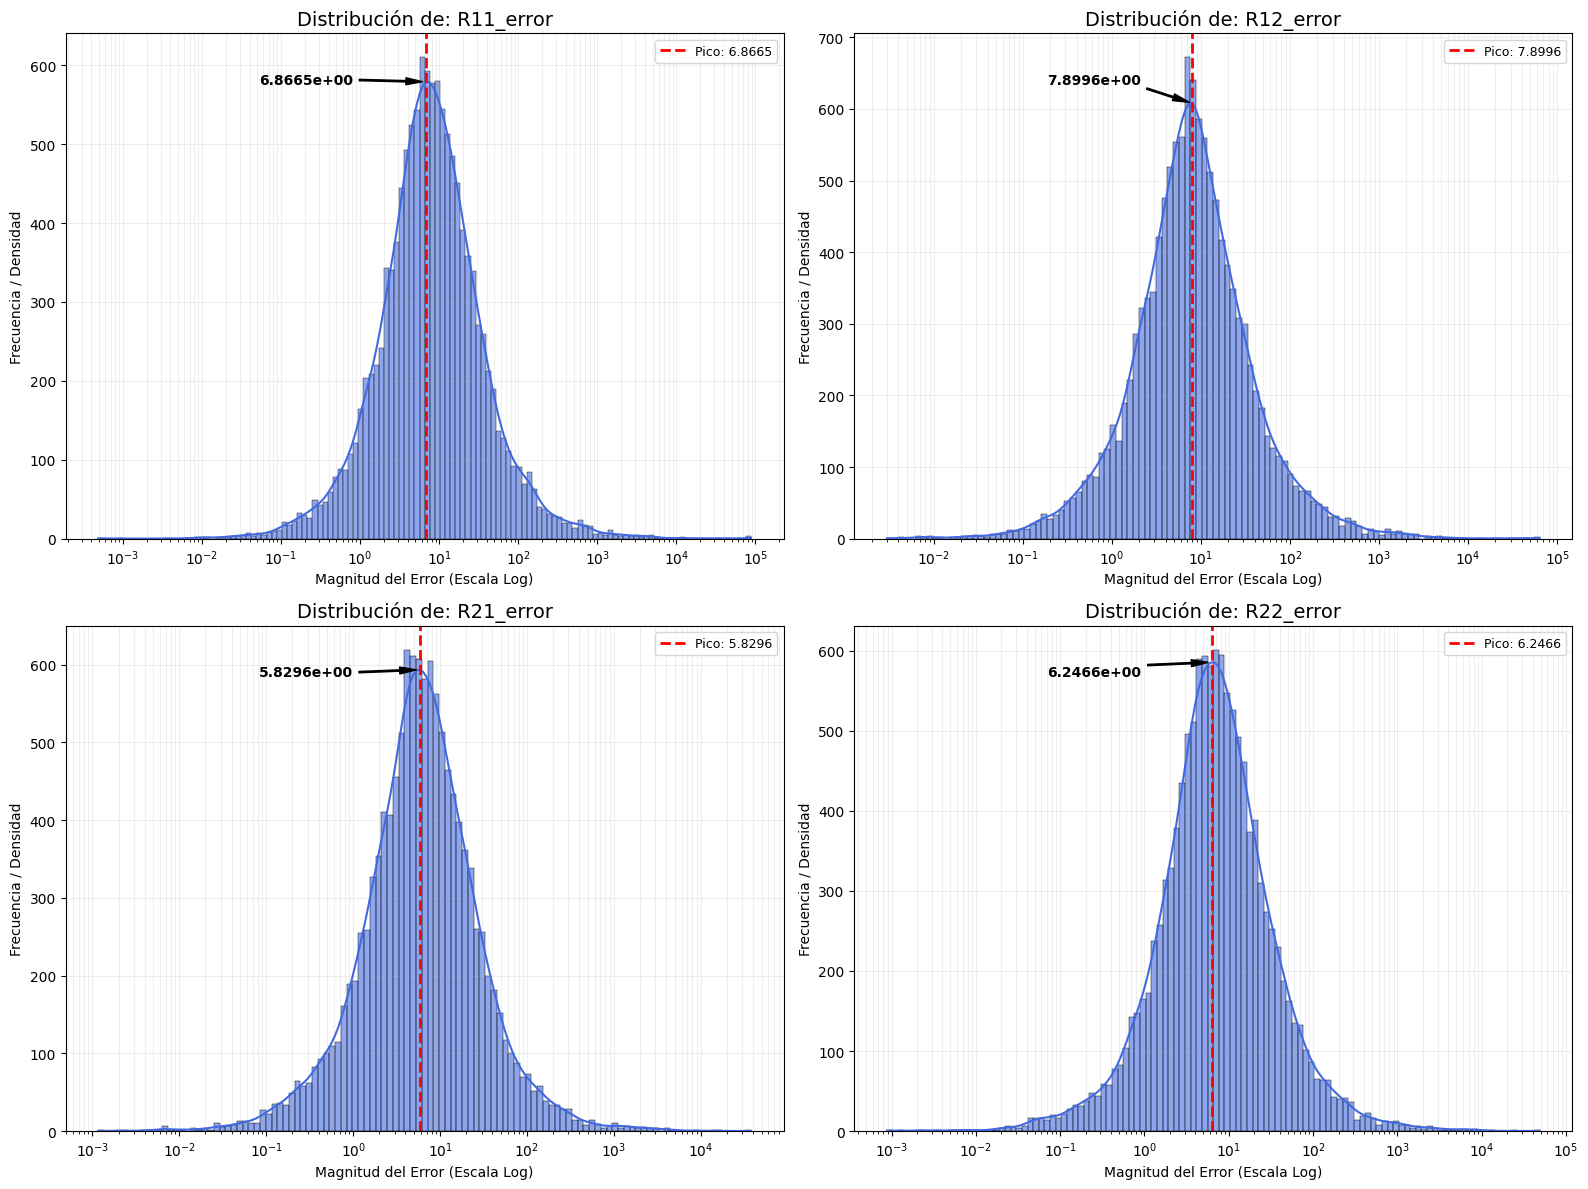

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define aquí los nombres de tus 4 columnas de error

# 2. Configurar la cuadrícula (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Convertimos la matriz 2x2 en una lista plana para iterar fácil

for i, col in enumerate(errores):
    ax = axes[i]
    
    # Crear el histplot en el eje correspondiente (ax)
    sns.histplot(df_test[col], kde=True, log_scale=True, color='royalblue', alpha=0.6, ax=ax)
    
    # Extraer los datos de la curva KDE
    if len(ax.lines) > 0:
        line = ax.lines[0]
        x, y = line.get_data()
        
        # Encontrar el pico de concentración
        idx_max = np.argmax(y)
        pico_error = x[idx_max]
        
        # Indicación visual
        ax.axvline(pico_error, color='red', linestyle='--', lw=2, label=f'Pico: {pico_error:.4f}')
        
        # Anotación (ajustada para escala log)
        ax.annotate(f'{pico_error:.4e}', 
                     xy=(pico_error, y[idx_max]), 
                     xytext=(0.4, 0.9), textcoords='axes fraction', # Posición relativa al subplot
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     fontsize=10, fontweight='bold', horizontalalignment='right')

    # Personalización de cada subplot
    ax.set_title(f'Distribución de: {col}', fontsize=14)
    ax.set_xlabel('Magnitud del Error (Escala Log)')
    ax.set_ylabel('Frecuencia / Densidad')
    #ax.set_xlim([0,100])
    ax.legend(fontsize=9)
    ax.grid(True, which="both", ls="-", alpha=0.2)

# Ajustar espacio entre gráficas para que no se encimen los títulos
plt.tight_layout()
plt.show()